<a href="https://colab.research.google.com/github/gcoelho3008/reconhecimento_facial/blob/main/reconhecimento_facial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Visão computacional com opnnCV

### **OpenCv**

In [1]:
!pip install opencv-contrib-python

In [2]:
from PIL import Image
from google.colab.patches import cv2_imshow
from google.colab import patches
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

import seaborn
import os
import cv2
import numpy as np
import zipfile

In [3]:
path = '/content/drive/MyDrive/Visão Computacional Guia Completo/Visão Computacional Guia Completo/Datasets/yalefaces.zip'
zip_object = zipfile.ZipFile(file=path, mode = 'r')
zip_object.extractall('./')
zip_object.close()

In [4]:
print(os.listdir('/content/yalefaces'))

['.DS_Store', 'test', 'train']


In [5]:
def get_image_data():
  paths = [os.path.join('/content/yalefaces/train', f) for f in os.listdir('/content/yalefaces/train')]
  faces = []
  ids = []
  for path in paths:
    imagem = Image.open(path).convert('L')
    imagem_np = np.array(imagem, 'uint8')
    id = int(os.path.split(path)[1].split('.')[0].replace('subject', ''))
    ids.append(id)
    faces.append(imagem_np)

  return np.array(ids), faces

In [6]:
ids, faces = get_image_data()

In [7]:
ids

array([ 6,  1, 12,  5,  3, 13, 15, 12, 15, 10,  4,  2,  9,  1, 15, 14,  4,
       15,  5,  3,  8,  8,  2,  7,  3,  6,  6,  6, 14,  2,  5,  2,  1,  2,
        5,  8, 10, 11, 13, 13, 10, 11,  5,  7, 12, 13,  5, 11,  9, 10, 12,
        3, 11,  5,  7,  9, 14,  2,  4,  6, 11,  7,  9, 15,  7,  6,  5,  1,
       15, 14,  2, 13,  6, 15,  7,  8,  8, 11, 14, 12,  8, 14,  2,  9,  9,
        8, 11, 13, 14,  4,  7, 12, 13,  8,  7,  6,  8, 14,  1,  4, 15, 10,
        1,  4,  1, 10, 12,  1,  6,  4,  3, 13,  9, 14,  3,  5, 10,  3,  9,
        4,  4, 10,  9, 15, 12, 13,  2, 10,  3,  1, 11,  3,  7, 12, 11])

In [8]:
len(ids)

135

In [9]:
faces[0], faces[0].shape

(array([[122, 112, 109, ..., 255, 255, 255],
        [255, 246, 241, ..., 255, 255, 255],
        [252, 244, 252, ..., 255, 255, 255],
        ...,
        [ 78,  79,  76, ..., 255, 255, 255],
        [ 79,  79,  76, ..., 255, 255, 255],
        [ 68,  68,  68, ...,  68,  68,  68]], dtype=uint8),
 (243, 320))

### Treinamento do classificador LBPH

In [10]:
8 * 8,9 * 9

(64, 81)

In [11]:
# threshold: 1.7976931348623157e+38
# radius: 1
# neighbors: 8
# grid_x: 8
# grid_y: 8

lbph_classifier = cv2.face.LBPHFaceRecognizer_create(radius=4, neighbors=14, grid_x=9, grid_y=9)
lbph_classifier.train(faces, ids)
lbph_classifier.write('lbph_classifier.yml')

### Reconhecimento de Faces

In [12]:
lbph_face_classifier = cv2.face.LBPHFaceRecognizer_create()
lbph_face_classifier.read('lbph_classifier.yml')

In [13]:
imagem_teste = '/content/yalefaces/test/subject10.sad.gif'

array([[130, 130, 130, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 241, 255, 255],
       [255, 255, 255, ..., 234, 237, 252],
       [ 68,  68,  68, ...,  68,  68,  68]], dtype=uint8)
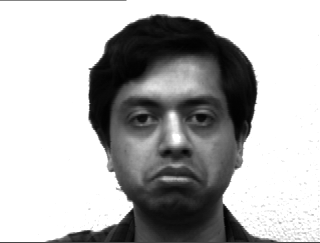

In [14]:
imagem = Image.open(imagem_teste).convert('L')
imagem_np = np.array(imagem, 'uint8')
imagem_np

In [15]:
imagem_np.shape

(243, 320)

In [16]:
previsao = lbph_face_classifier.predict(imagem_np)
previsao

(10, 36.84750714043355)

In [17]:
previsao[0]

10

In [18]:
saida_esperada = int(os.path.split(imagem_teste)[1].split('.')[0].replace('subject', ''))
saida_esperada

10

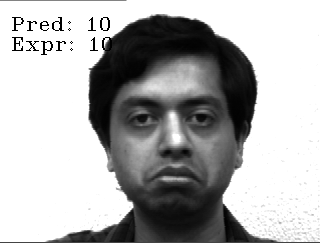

In [19]:
cv2.putText(imagem_np, 'Pred: ' + str(previsao[0]), (10, 30), cv2.FONT_HERSHEY_COMPLEX_SMALL, 1, (0, 255, 0))
cv2.putText(imagem_np, 'Expr: ' + str(saida_esperada), (10,50), cv2.FONT_HERSHEY_COMPLEX_SMALL, 1, (0, 255, 0))
cv2_imshow(imagem_np)


### Avaliação do Classificador

In [20]:
paths = [os.path.join('/content/yalefaces/test', f) for f in os.listdir('/content/yalefaces/test')]
previsoes = []
saidas_esperadas = []
for path in paths:
 # print(path)
  imagem = Image.open(path).convert('L')
  imagem_np = np.array(imagem, 'uint8')
  previsao, _ = lbph_face_classifier.predict(imagem_np)
 # print(previsao)
  saida_esperada = int(os.path.split(path)[1].split('.')[0].replace('subject', ''))
  #print(saida_esperada)

  previsoes.append(previsao)
  saidas_esperadas.append(saida_esperada)

In [21]:
type(previsoes), type(saidas_esperadas)

(list, list)

In [22]:
previsoes = np.array(previsoes)
saidas_esperadas = np.array(saidas_esperadas)

In [23]:
type(previsoes), type(saidas_esperadas)


(numpy.ndarray, numpy.ndarray)

In [24]:
previsoes

array([12, 13,  4, 12,  7, 15,  4, 14,  8, 11,  4, 12, 11, 13,  6,  5,  7,
        5,  4,  9, 10,  3, 14,  4,  7,  9, 14,  4,  3,  1])

In [25]:
saidas_esperadas

array([12, 13, 10,  2, 15, 15,  8,  6,  8, 11,  4, 12, 11, 13,  6,  5,  9,
        5,  2,  9, 10,  3, 14,  1,  7,  7, 14,  4,  3,  1])

In [26]:
accuracy_score(saidas_esperadas, previsoes)

0.7

In [27]:
len(previsoes)

30

In [28]:
cm = confusion_matrix(saidas_esperadas, previsoes)
cm

array([[1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1]])

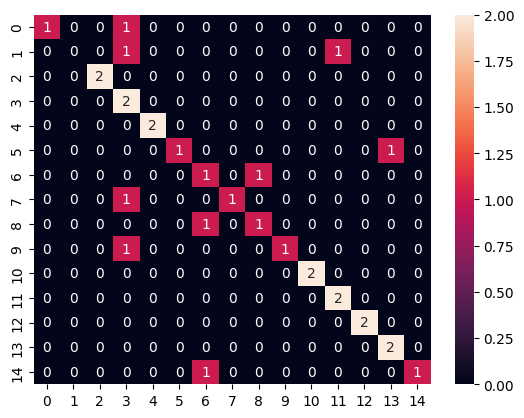

In [29]:
seaborn.heatmap(cm, annot=True);

In [30]:
acc = accuracy_score(saidas_esperadas, previsoes)
print(f'Acurácia: {acc*100:.2f}%')

Acurácia: 70.00%


### Detecção de pontos faciais com dlib

In [31]:
import dlib

In [32]:
detector_face = dlib.get_frontal_face_detector()
detector_pontos = dlib.shape_predictor('/content/drive/MyDrive/Visão Computacional Guia Completo/Visão Computacional Guia Completo/Weights/shape_predictor_68_face_landmarks.dat')


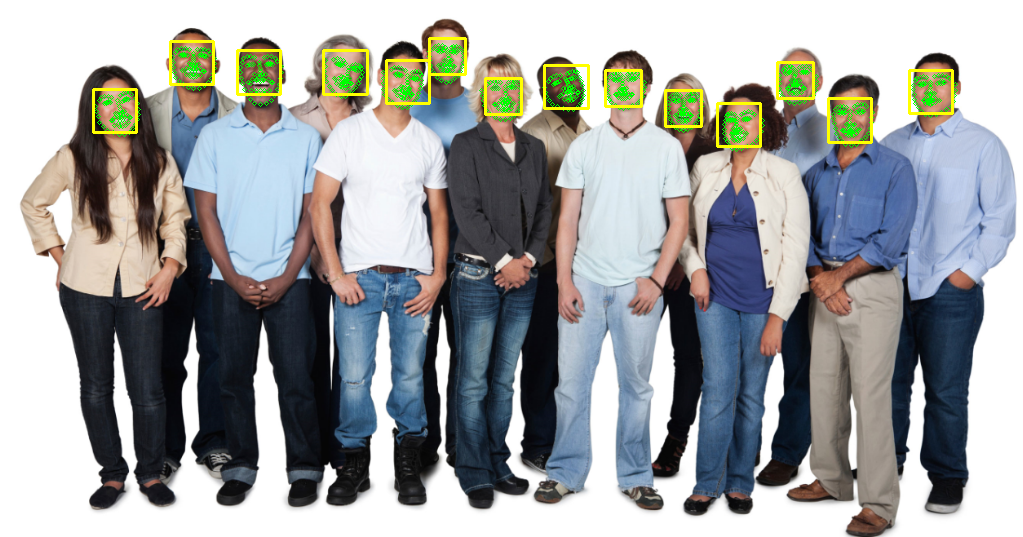

In [38]:
imagem = cv2.imread('/content/drive/MyDrive/Visão Computacional Guia Completo/Visão Computacional Guia Completo/Images/people2.jpg')
deteccoes = detector_face(imagem, 1)
for face in deteccoes:
  pontos = detector_pontos(imagem, face)
  for ponto in pontos.parts():
    cv2.circle(imagem, (ponto.x, ponto.y), 2, (0, 255, 0), 1)
  #print(pontos.parts())
  #print(len(pontos.parts()))

  l, t, r, b = face.left(), face.top(), face.right(), face.bottom()
  cv2.rectangle(imagem, (l, t), (r, b), (0, 255, 255), 2)
cv2_imshow(imagem)


### Detecção de descritores faciais

In [39]:
#Resnet:  https://arxiv.org/abs/1512.03385
detector_face = dlib.get_frontal_face_detector()
detector_pontos = dlib.shape_predictor('/content/drive/MyDrive/Visão Computacional Guia Completo/Visão Computacional Guia Completo/Weights/shape_predictor_68_face_landmarks.dat')
descritor_facial_extrator = dlib.face_recognition_model_v1('/content/drive/MyDrive/Visão Computacional Guia Completo/Visão Computacional Guia Completo/Weights/dlib_face_recognition_resnet_model_v1.dat')

In [41]:
from numpy._core.defchararray import index
index = {}
idx = 0
descritores_faciais = None

paths = [os.path.join('/content/yalefaces/train', f) for f in os.listdir('/content/yalefaces/train')]
for path in paths:
 # print(path)
  imagem = Image.open(path).convert('RGB')
  imagem_np = np.array(imagem, 'uint8')
  deteccoes = detector_face(imagem_np, 1)
  for face in deteccoes:
    l, t, r, b = face.left(), face.top(), face.right(), face.bottom()
    cv2.rectangle(imagem_np, (l, t), (r, b), (0, 0, 255), 2)

    pontos = detector_pontos(imagem_np, face)
    for ponto in pontos.parts():
      cv2.circle(imagem_np, (ponto.x, ponto.y), 2, (0, 255, 0), 1)

      descritor_facial = descritor_facial_extrator.compute_face_descriptor(imagem_np, pontos)
      descritor_facial = [f for f in descritor_facial]
      descritor_facial = np.asarray(descritor_facial, dtype=np.float64)
      descritor_facial = descritor_facial[np.newaxis, :]

      if descritores_faciais is None:
        descritores_faciais = descritor_facial
      else:
        descritores_faciais = np.concatenate((descritores_faciais, descritor_facial), axis = 0)
      index[idx] = path
      idx += 1
   # cv2_imshow(imagem_np)

In [42]:
descritores_faciais.shape

(8976, 128)

In [43]:
descritores_faciais

array([[-0.09340024,  0.1241345 ,  0.03203325, ..., -0.02285987,
         0.02258098,  0.0281721 ],
       [-0.09319633,  0.12237903,  0.0317262 , ..., -0.0200363 ,
         0.02188663,  0.02843849],
       [-0.09494694,  0.12120923,  0.03076431, ..., -0.01871372,
         0.02285173,  0.02739326],
       ...,
       [-0.13917778,  0.10212002, -0.0262384 , ...,  0.01474897,
         0.09298875,  0.02160436],
       [-0.14048167,  0.10236111, -0.02427291, ...,  0.01386824,
         0.09258293,  0.02266999],
       [-0.14048167,  0.10236111, -0.02427291, ...,  0.01386824,
         0.09258293,  0.02266999]])

In [ ]:
index

In [45]:
len(index)

8976

### Cálculo da distancia entre faces

In [ ]:
descritores_faciais[131]

In [47]:
np.linalg.norm(descritores_faciais[131] - descritores_faciais[131])


np.float64(0.0)

In [48]:
np.linalg.norm(descritores_faciais[131] - descritores_faciais[130])

np.float64(0.010964338950137606)

In [49]:
np.linalg.norm(descritores_faciais[131] - descritores_faciais[129])

np.float64(0.022555677684354635)

In [50]:
np.linalg.norm(descritores_faciais[131] - descritores_faciais[128])

np.float64(0.03355403274454325)

In [51]:
np.linalg.norm(descritores_faciais[131] - descritores_faciais[119])

np.float64(0.060749067909321476)

In [52]:
np.linalg.norm(descritores_faciais[0] - descritores_faciais, axis = 1)


array([0.        , 0.01484864, 0.02371204, ..., 0.7132689 , 0.71185685,
       0.71185685])

In [53]:
np.argmin(np.linalg.norm(descritores_faciais[0] - descritores_faciais[1:], axis = 1))

np.int64(0)

In [54]:
np.linalg.norm(descritores_faciais[0] - descritores_faciais[1:], axis = 1)[18]

np.float64(0.12655196600414895)

### Detecção de Faces com Dlib

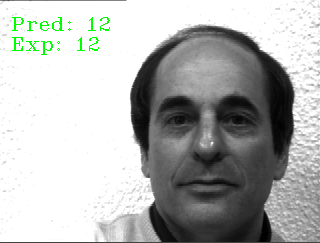

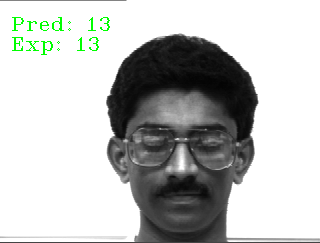

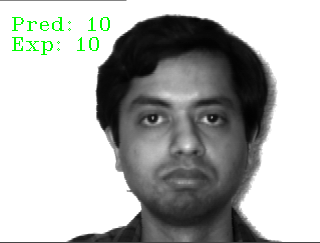

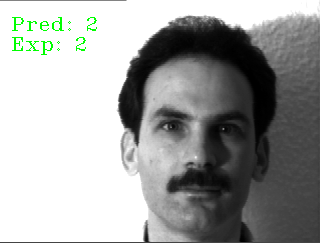

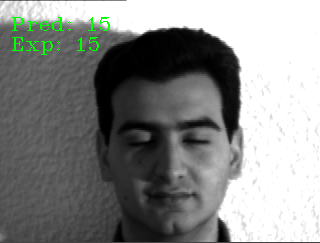

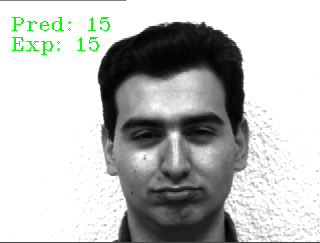

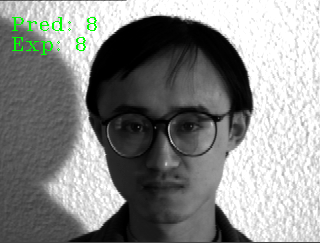

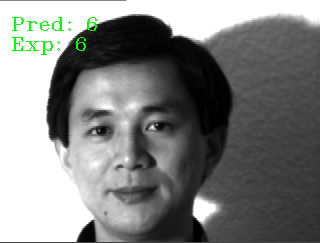

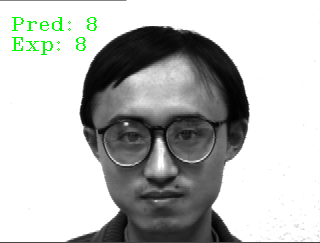

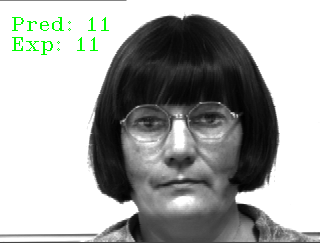

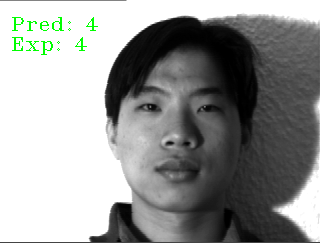

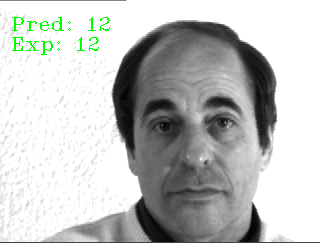

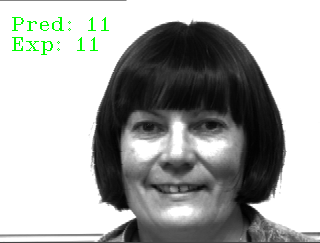

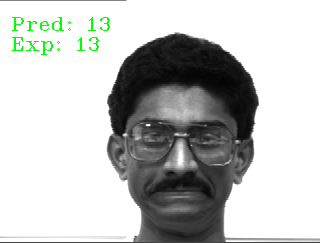

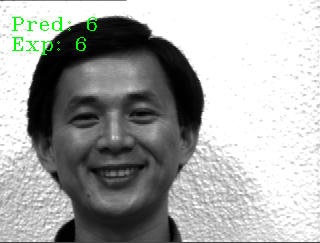

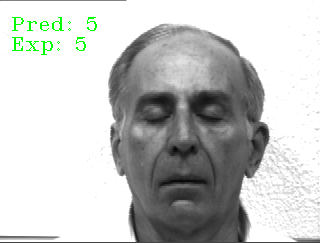

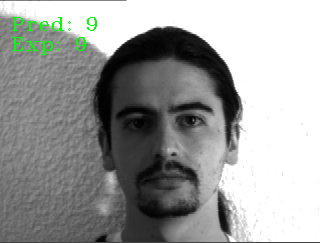

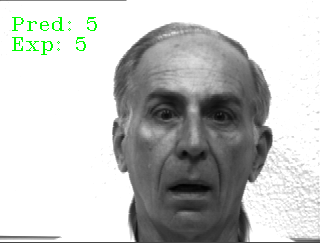

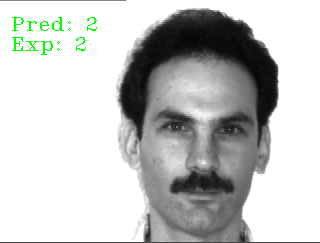

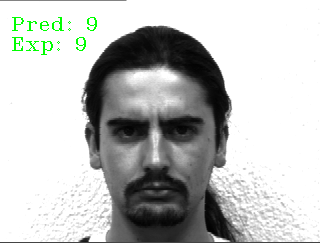

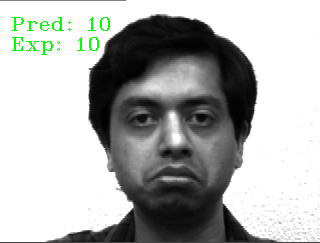

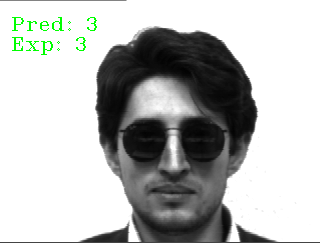

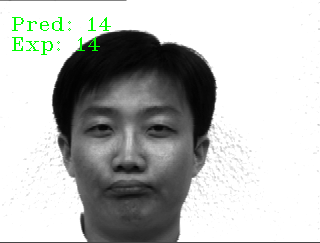

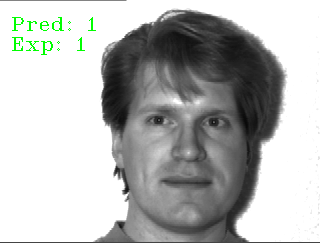

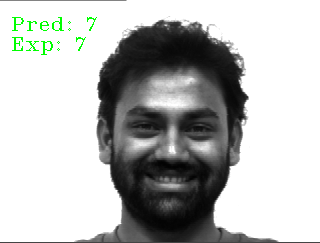

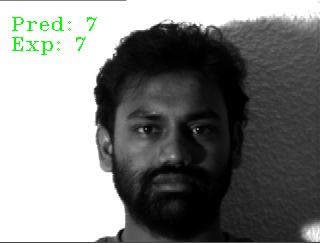

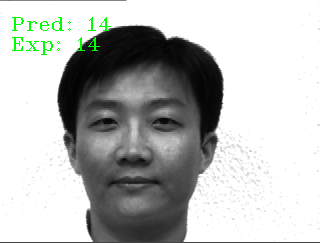

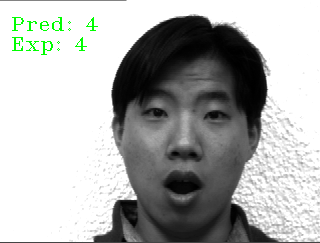

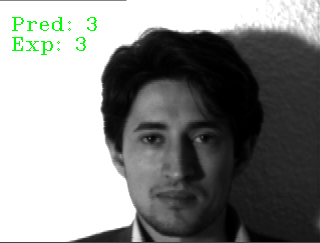

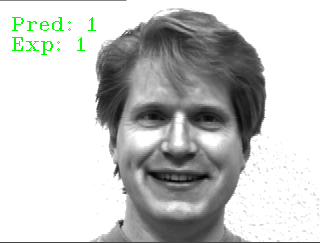

In [73]:
confianca = 0.5
previsoes = []
saidas_esperadas = []

paths = [os.path.join('/content/yalefaces/test', f) for f in os.listdir('/content/yalefaces/test')]
for path in paths:
  #print(path)
  imagem = Image.open(path).convert('RGB')
  imagem_np = np.array(imagem, 'uint8')
  deteccoes = detector_face(imagem_np, 1)
  for face in deteccoes:
    pontos = detector_pontos(imagem_np, face)
    descritor_facial = descritor_facial_extrator.compute_face_descriptor(imagem_np, pontos)
    descritor_facial = [f for f in descritor_facial]
    descritor_facial = np.asarray(descritor_facial, dtype=np.float64)
    descritor_facial = descritor_facial[np.newaxis, :]

    distancias = np.linalg.norm(descritor_facial - descritores_faciais, axis = 1)
    indice_minimo = np.argmin(distancias)
    distancia_minima = distancias[indice_minimo]
    if distancia_minima <= confianca:
      nome_previsao = int(os.path.split(index[indice_minimo])[1].split('.')[0].replace('subject', ''))
    else:
      nome_previsao = 'Face não identificada'

    nome_real = int(os.path.split(path)[1].split('.')[0].replace('subject', ''))

    previsoes.append(nome_previsao)
    saidas_esperadas.append(nome_real)

    cv2.putText(imagem_np, 'Pred: ' + str(nome_previsao), (10,30), cv2.FONT_HERSHEY_COMPLEX_SMALL, 1, (0,255,0))
    cv2.putText(imagem_np, 'Exp: ' + str(nome_real), (10,50), cv2.FONT_HERSHEY_COMPLEX_SMALL, 1, (0,255,0))

  cv2_imshow(imagem_np)

previsoes = np.array(previsoes)
saidas_esperadas = np.array(saidas_esperadas)

In [74]:
previsoes

array([12, 13, 10,  2, 15, 15,  8,  6,  8, 11,  4, 12, 11, 13,  6,  5,  9,
        5,  2,  9, 10,  3, 14,  1,  7,  7, 14,  4,  3,  1])

In [75]:
saidas_esperadas

array([12, 13, 10,  2, 15, 15,  8,  6,  8, 11,  4, 12, 11, 13,  6,  5,  9,
        5,  2,  9, 10,  3, 14,  1,  7,  7, 14,  4,  3,  1])

In [76]:
accuracy_score(saidas_esperadas, previsoes)

1.0